X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)
Test Accuracy: 0.933


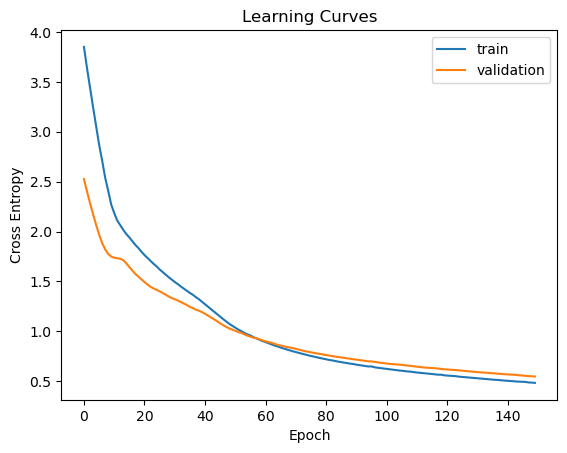

In [4]:
import numpy as np
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from matplotlib import pyplot

# Load dataset
df = read_csv('Iris.csv')

# Separate input and output
# Ignore Id column and Species column
X = df.values[:, 1:-1]
y = df.values[:, -1]

# Convert input values to float
X = X.astype('float32')

# Convert species names to numbers
# Setosa = 0, Versicolor = 1, Virginica = 2
y = LabelEncoder().fit_transform(y)

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=123
)

print("X_train shape: {}".format(X_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))

# Split training data into training and validation data
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=1
)

# Determine number of input features
n_features = X_train.shape[1]

# Define the model
model = Sequential()

model.add(Input(shape=(n_features,)))

model.add(Dense(
    10,
    activation='relu',
    kernel_initializer='he_normal'
))

model.add(Dense(
    8,
    activation='relu',
    kernel_initializer='he_normal'
))

model.add(Dense(
    3,
    activation='softmax'
))

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=32,
    verbose=0,
    validation_data=(X_val, y_val)
)

# Evaluate the model
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print('Test Accuracy: %.3f' % acc)

# Plot learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')

pyplot.plot(
    history.history['loss'],
    label='train'
)

pyplot.plot(
    history.history['val_loss'],
    label='validation'
)

pyplot.legend()
pyplot.show()
